# LinkedIn Job Postings — Market Segmentation via Clustering

**Goal:** segment LinkedIn job postings into meaningful market clusters using
**salary, required skills, experience level, and remote-work availability**,
so that recruiters, job-seekers, or analysts can quickly understand the
shape of the job market and where a given posting (or a candidate's target
role) fits in.

**Approach:** unsupervised learning with **K-Means**, model order selected
via the **elbow method** and **silhouette score**.

**Pipeline stages**
1. Load & merge raw LinkedIn data (postings + job skills)
2. Exploratory data analysis (EDA)
3. Data cleaning & filtering
4. Feature engineering
5. Preprocessing pipeline (scaling + encoding)
6. Model selection (elbow + silhouette)
7. Final K-Means model + cluster profiling
8. Visualization
9. Persist artifacts for the Streamlit app

> All feature-engineering logic lives in `src/preprocessing.py` and is
> imported here *and* by `app.py`, so the deployed app transforms new job
> postings identically to how this notebook transformed the training data.


In [1]:
import sys, os, json, io, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML

# ── locate src/preprocessing.py ─────────────────────────────────────────────
# Search common locations relative to where this notebook file sits
_nb_dir = pathlib.Path().resolve()   # current working directory of Jupyter
for _candidate in [
    _nb_dir / "src",           # notebook IS in project root
    _nb_dir.parent / "src",    # notebook is in  project/notebooks/
    _nb_dir / "../src",
]:
    _c = _candidate.resolve()
    if _c.is_dir() and (_c / "preprocessing.py").exists():
        sys.path.insert(0, str(_c))
        break

import preprocessing as prep

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

# ── output folders: always created BESIDE the notebook, never in system dirs ─
DATA_PROCESSED = str(_nb_dir / "output" / "data")
MODELS_DIR     = str(_nb_dir / "output" / "models")
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(MODELS_DIR,     exist_ok=True)
print(f"📁 Outputs will be saved to:  {_nb_dir / 'output'}")

# ── FILE UPLOAD WIDGETS ──────────────────────────────────────────────────────
display(HTML("""
<div style="background:#1e3a5f;padding:14px 18px;border-radius:8px;margin:10px 0">
  <h3 style="color:#7eb8f7;margin:0 0 6px 0">📂 Upload your LinkedIn CSV files</h3>
  <p style="color:#cce0ff;margin:0">
    Click each button and select the file from anywhere on your PC.
    All three must be uploaded before running the next cell.
  </p>
</div>
"""))

up_postings   = widgets.FileUpload(accept=".csv", description="postings.csv",
                                    layout=widgets.Layout(width="220px"))
up_job_skills = widgets.FileUpload(accept=".csv", description="job_skills.csv",
                                    layout=widgets.Layout(width="220px"))
up_skills_map = widgets.FileUpload(accept=".csv", description="skills.csv",
                                    layout=widgets.Layout(width="220px"))

status_lbl = widgets.HTML(value="<span style='color:orange'>⏳ Waiting for uploads…</span>")

def _on_change(change):
    done = sum(1 for w in (up_postings, up_job_skills, up_skills_map) if w.value)
    if done == 3:
        status_lbl.value = "<span style='color:limegreen'>✅ All 3 files uploaded — run the next cell!</span>"
    else:
        status_lbl.value = f"<span style='color:orange'>⏳ {done}/3 files uploaded…</span>"

for w in (up_postings, up_job_skills, up_skills_map):
    w.observe(_on_change, names="value")

display(widgets.VBox([
    widgets.HBox([up_postings, up_job_skills, up_skills_map],
                 layout=widgets.Layout(gap="12px", margin="10px 0")),
    status_lbl,
]))


## 1. Load & Merge Raw Data

We load `postings.csv` (the core job-posting table) and `job_skills.csv`
(a long-format job_id → skill_category table), and pivot the skills into
one binary column per skill category (35 LinkedIn skill categories total).


In [2]:
def _widget_to_df(widget, name):
    """Read a FileUpload widget value into a pandas DataFrame."""
    if not widget.value:
        raise ValueError(f"No file uploaded for '{name}'. "
                         "Please upload it in the cell above, then re-run this cell.")
    content = list(widget.value.values())[0]["content"]   # raw bytes
    return pd.read_csv(io.BytesIO(content))

# ── load three CSVs from the upload widgets ──────────────────────────────────
usecols = [
    "job_id", "company_name", "company_id",
    "title", "location",
    "formatted_work_type", "formatted_experience_level",
    "remote_allowed", "normalized_salary", "currency", "pay_period",
    "views",
]

_postings_bytes   = io.BytesIO(list(up_postings.value.values())[0]["content"])
_job_skills_bytes = io.BytesIO(list(up_job_skills.value.values())[0]["content"])
_skills_map_bytes = io.BytesIO(list(up_skills_map.value.values())[0]["content"])

# ── use the shared helper (which accepts file paths OR IO objects) ───────────
# We manually replicate the merge here with the byte-stream DataFrames
# so we don't need temporary files.
postings   = pd.read_csv(_postings_bytes, usecols=usecols)
job_skills = pd.read_csv(_job_skills_bytes)
skills_map = pd.read_csv(_skills_map_bytes)   # not used directly below but validates file

SKILL_COLUMNS = prep.SKILL_COLUMNS

skill_pivot = (
    job_skills.assign(flag=1)
    .pivot_table(index="job_id", columns="skill_abr", values="flag", fill_value=0)
)
for col in SKILL_COLUMNS:
    if col not in skill_pivot.columns:
        skill_pivot[col] = 0
skill_pivot = skill_pivot[SKILL_COLUMNS].astype(int)
skill_pivot["num_skills"] = skill_pivot[SKILL_COLUMNS].sum(axis=1)

df_raw = postings.merge(skill_pivot, on="job_id", how="left")
df_raw[SKILL_COLUMNS + ["num_skills"]] = df_raw[SKILL_COLUMNS + ["num_skills"]].fillna(0)

print(f"✅ Loaded {df_raw.shape[0]:,} job postings with {df_raw.shape[1]} columns")
df_raw.head(3)


Loaded 123,849 job postings with 47 columns


,job_id,company_name,title,pay_period,location,views,formatted_work_type,remote_allowed,formatted_experience_level,currency,...,PROD,QA,RSCH,SALE,SCI,STRA,SUPL,TRNG,WRT,num_skills
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,HOURLY,"Princeton, NJ",20.0,Full-time,NaN,NaN,USD,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
1,1829192,NaN,Mental Health Therapist/Counselor,HOURLY,"Fort Collins, CO",1.0,Full-time,NaN,NaN,USD,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,YEARLY,"Cincinnati, OH",8.0,Full-time,NaN,NaN,USD,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


## 2. Exploratory Data Analysis

Before engineering features, let's understand the data: missingness,
salary distribution, experience-level mix, and skill frequency.


In [3]:
missing = df_raw.isna().mean().sort_values(ascending=False)
missing[missing > 0]


remote_allowed                0.876898
currency                      0.708734
pay_period                    0.708734
normalized_salary             0.708734
formatted_experience_level    0.237459
company_name                  0.013880
views                         0.013638
dtype: float64

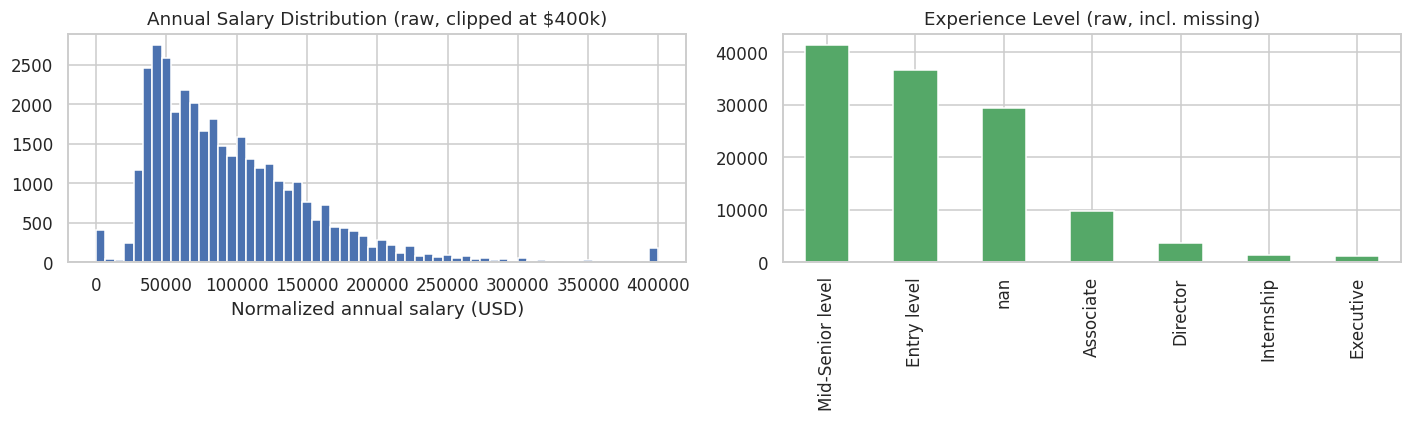

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_raw["normalized_salary"].dropna().clip(upper=400_000).hist(bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Annual Salary Distribution (raw, clipped at $400k)")
axes[0].set_xlabel("Normalized annual salary (USD)")

df_raw["formatted_experience_level"].value_counts(dropna=False).plot(
    kind="bar", ax=axes[1], color="#55A868"
)
axes[1].set_title("Experience Level (raw, incl. missing)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()


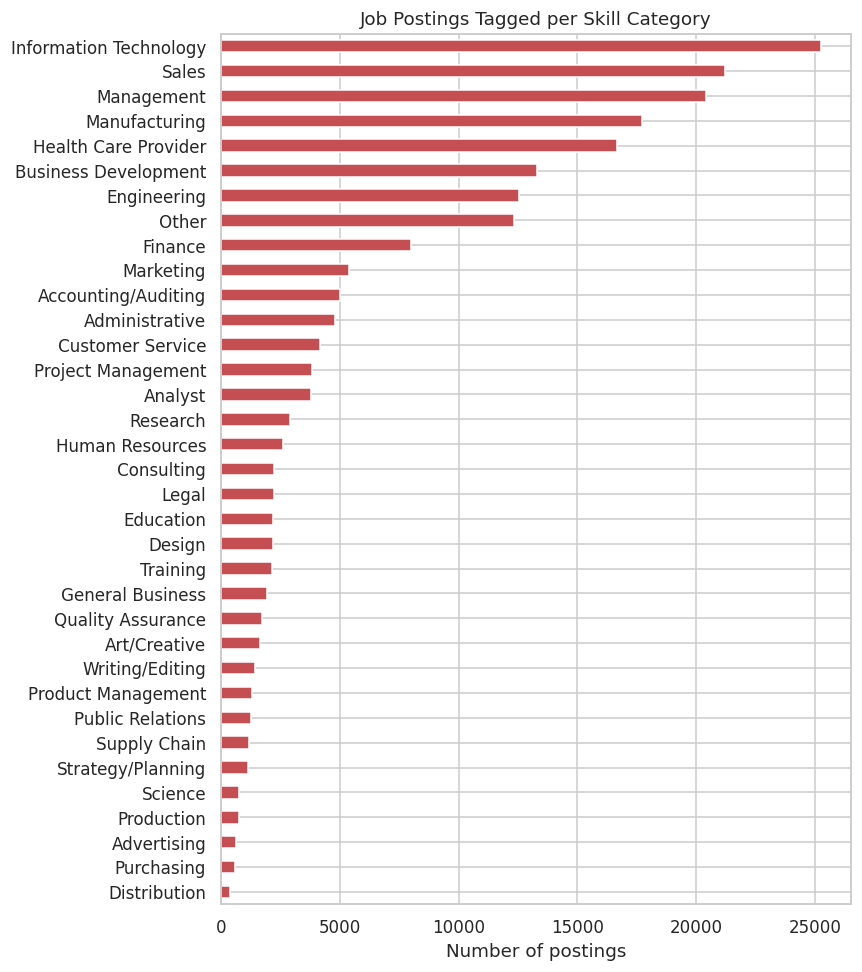

In [5]:
skill_freq = df_raw[prep.SKILL_COLUMNS].sum().sort_values(ascending=False)
skill_freq.index = [prep.SKILL_MAP[a] for a in skill_freq.index]

plt.figure(figsize=(8, 9))
skill_freq.plot(kind="barh", color="#C44E52")
plt.gca().invert_yaxis()
plt.title("Job Postings Tagged per Skill Category")
plt.xlabel("Number of postings")
plt.tight_layout()
plt.show()


**Takeaways:**
- Salary is present for roughly a third of postings, and is right-skewed →
  a log transform will help K-Means (which uses Euclidean distance).
- `formatted_experience_level` and `remote_allowed` both have substantial
  missingness — we'll treat "missing" as its own informative category
  rather than dropping those rows.
- IT, Sales, and Management are the most commonly tagged skill categories.


## 3. Data Cleaning & Filtering

For a salary-aware clustering, we need a real, plausible salary figure.
We keep postings that are:
- priced in **USD** (currency consistency — avoids mixing FX rates), and
- have a `normalized_salary` between **\$15,000 and \$500,000/year**
  (values outside this band are almost always data-entry errors, e.g. an
  hourly rate stored as if it were annual).

For the remaining engineered features, missing experience level and
missing remote-flag are kept as explicit categories rather than dropped,
to avoid losing the (large) population of postings that simply don't
specify them.


In [6]:
df_clean = prep.clean_and_filter(df_raw)
print(f"Before filtering: {len(df_raw):,} postings")
print(f"After filtering:  {len(df_clean):,} postings "
      f"({len(df_clean)/len(df_raw):.1%} retained)")


Before filtering: 123,849 postings
After filtering:  35,509 postings (28.7% retained)


## 4. Feature Engineering

| Raw column | Engineered feature | Transform |
|---|---|---|
| `normalized_salary` | `log_salary` | `log1p` (fix right-skew) |
| `formatted_experience_level` | `experience_rank` | ordinal: Not Specified(-1) → Executive(5) |
| `formatted_work_type` | `work_type` | tidied category for one-hot encoding |
| `remote_allowed` | `remote_allowed` | clean binary 0/1 |
| 35 skill flags | `ART`...`WRT` | already binary (multi-hot from job_skills.csv) |
| skill flags | `num_skills` | count of distinct skill categories tagged |

This logic lives in `preprocessing.engineer_features()` so it can be reused
verbatim by the Streamlit app at inference time.


In [7]:
df_feat = prep.engineer_features(df_clean)
feature_cols = prep.get_feature_columns()
print(f"Model will use {len(feature_cols)} engineered feature columns:")
print(feature_cols)
df_feat[feature_cols].head(3)


Model will use 40 engineered feature columns:
['log_salary', 'experience_rank', 'num_skills', 'work_type', 'remote_allowed', 'ACCT', 'ADM', 'ADVR', 'ANLS', 'ART', 'BD', 'CNSL', 'CUST', 'DIST', 'DSGN', 'EDU', 'ENG', 'FIN', 'GENB', 'HCPR', 'HR', 'IT', 'LGL', 'MGMT', 'MNFC', 'MRKT', 'OTHR', 'PR', 'PRCH', 'PRDM', 'PRJM', 'PROD', 'QA', 'RSCH', 'SALE', 'SCI', 'STRA', 'SUPL', 'TRNG', 'WRT']


,log_salary,experience_rank,num_skills,work_type,remote_allowed,ACCT,ADM,ADVR,ANLS,ART,...,PRJM,PROD,QA,RSCH,SALE,SCI,STRA,SUPL,TRNG,WRT
0,10.557920,-1,2.0,Full-time,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,11.329015,-1,1.0,Full-time,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,10.915107,-1,2.0,Full-time,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. Preprocessing Pipeline

A single `ColumnTransformer` (from `preprocessing.build_preprocessor()`)
applies:
- **StandardScaler** to the 3 numeric features (`log_salary`,
  `experience_rank`, `num_skills`)
- **OneHotEncoder** to `work_type`
- **passthrough** for the 36 already-binary features (`remote_allowed` +
  35 skill flags)

We fit it once on the training data and persist it (`models/preprocessor.pkl`)
so the exact same fitted scaler/encoder is reused by the Streamlit app —
never refit on new data.


In [8]:
preprocessor = prep.build_preprocessor()
X = preprocessor.fit_transform(df_feat[feature_cols])
print("Final feature matrix shape:", X.shape)


Final feature matrix shape: (35509, 46)


## 6. Model Selection — Elbow Method & Silhouette Score

We fit K-Means for k = 2..10 and track:
- **Inertia** (within-cluster sum of squares) → elbow method
- **Silhouette score** (sampled at 5,000 points for tractability) → cluster
  separation quality


In [9]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=5000, random_state=RANDOM_STATE))
    print(f"k={k:>2}  inertia={km.inertia_:>12,.0f}  silhouette={silhouettes[-1]:.4f}")


k= 2  inertia=     142,270  silhouette=0.1809


k= 3  inertia=     124,404  silhouette=0.1648


k= 4  inertia=     111,680  silhouette=0.1565


k= 5  inertia=     101,548  silhouette=0.1673


k= 6  inertia=      96,643  silhouette=0.1570


k= 7  inertia=      92,325  silhouette=0.1662


k= 8  inertia=      88,666  silhouette=0.1728


k= 9  inertia=      85,658  silhouette=0.1693


k=10  inertia=      83,138  silhouette=0.1559


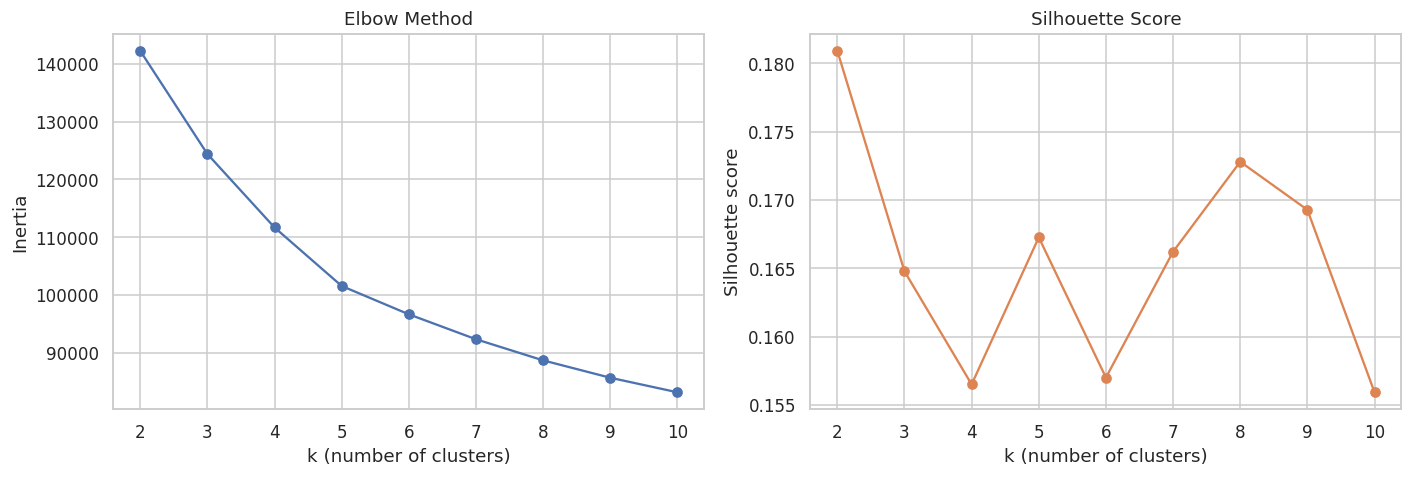

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()


**Choosing k:** the elbow flattens noticeably after **k≈5**, and k=5 sits
at a local peak in the silhouette curve (clearly better than k=4 or k=6).
It also lands in a practical sweet spot: enough clusters to separate
distinct market segments (entry-level vs. senior, technical vs.
operational, etc.) without producing clusters too small or too narrow to
act on.

**We proceed with k = 5.**


In [11]:
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X)
df_feat["cluster"] = cluster_labels

print(f"Final silhouette score (k={K_FINAL}): "
      f"{silhouette_score(X, cluster_labels, sample_size=5000, random_state=RANDOM_STATE):.4f}")
df_feat["cluster"].value_counts().sort_index()


Final silhouette score (k=5): 0.1673


cluster
0    7657
1    6738
2    7910
3    5331
4    7873
Name: count, dtype: int64

## 7. Cluster Profiling

For each cluster we summarize the median salary, dominant experience
level, dominant work type, remote-work share, and top skill categories —
then auto-generate a short, human-readable label.


In [12]:
def label_cluster(row):
    salary_tier = "High-Pay" if row["median_salary"] >= 90_000 else (
                  "Mid-Pay" if row["median_salary"] >= 60_000 else "Entry-Pay")
    return f"{salary_tier} · {row['top_experience']} · {row['top_skill']}"

profiles = []
for c in sorted(df_feat["cluster"].unique()):
    sub = df_feat[df_feat["cluster"] == c]
    top_skill_abr = sub[prep.SKILL_COLUMNS].mean().idxmax()
    profiles.append({
        "cluster": int(c),
        "n_postings": int(len(sub)),
        "median_salary": float(sub["normalized_salary"].median()),
        "top_experience": sub["formatted_experience_level"].mode().iat[0],
        "top_work_type": sub["work_type"].mode().iat[0],
        "remote_share": float(sub["remote_allowed"].mean()),
        "avg_num_skills": float(sub["num_skills"].mean()),
        "top_skill": prep.SKILL_MAP[top_skill_abr],
        "top_3_skills": ", ".join(
            prep.SKILL_MAP[a] for a in sub[prep.SKILL_COLUMNS].mean().sort_values(ascending=False).head(3).index
        ),
    })

profiles_df = pd.DataFrame(profiles)
profiles_df["label"] = profiles_df.apply(label_cluster, axis=1)
profiles_df = profiles_df.sort_values("median_salary", ascending=False).reset_index(drop=True)
profiles_df


,cluster,n_postings,median_salary,top_experience,top_work_type,remote_share,avg_num_skills,top_skill,top_3_skills,label
0,4,7873,117500.0,Mid-Senior level,Full-time,0.196875,2.362632,Information Technology,"Information Technology, Sales, Engineering",High-Pay · Mid-Senior level · Information Tech...
1,0,7657,115000.0,Mid-Senior level,Full-time,0.176309,1.000000,Information Technology,"Information Technology, Health Care Provider, ...",High-Pay · Mid-Senior level · Information Tech...
2,3,5331,113650.0,Not Specified,Full-time,0.175014,1.822735,Information Technology,"Information Technology, Sales, Engineering",High-Pay · Not Specified · Information Technology
3,1,6738,50000.0,Entry level,Full-time,0.085040,0.925200,Other,"Other, Health Care Provider, Administrative",Entry-Pay · Entry level · Other
4,2,7910,46800.0,Entry level,Full-time,0.045765,2.211884,Management,"Management, Manufacturing, Sales",Entry-Pay · Entry level · Management


## 8. Visualization

### 8.1 PCA projection (2D)
Project the 46-dimensional feature space down to 2D with PCA purely for
visualization (clustering itself was done on the full feature space, not
on these 2 components).


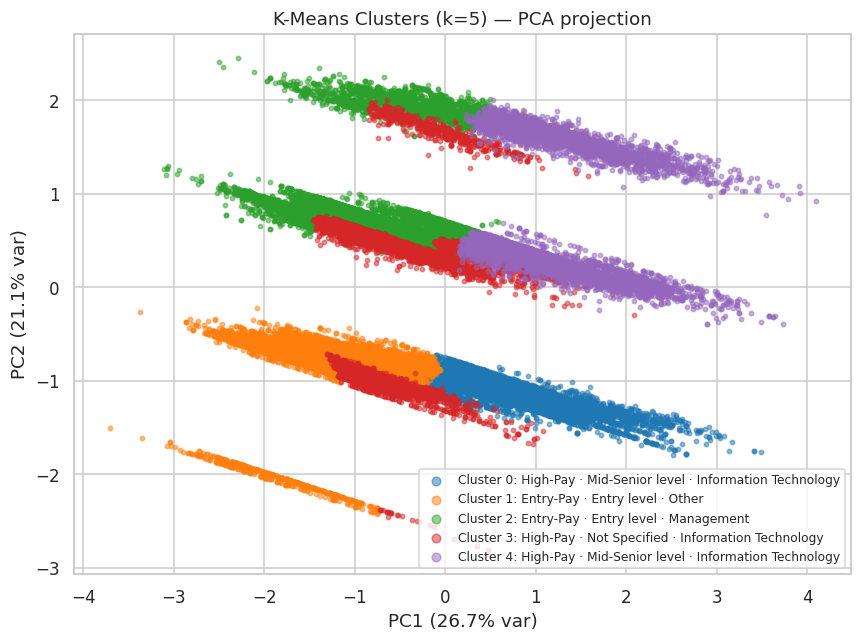

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
df_feat["pca_1"], df_feat["pca_2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", n_colors=K_FINAL)
for c in sorted(df_feat["cluster"].unique()):
    sub = df_feat[df_feat["cluster"] == c]
    label = profiles_df.loc[profiles_df["cluster"] == c, "label"].iat[0]
    plt.scatter(sub["pca_1"], sub["pca_2"], s=8, alpha=0.5, color=palette[c], label=f"Cluster {c}: {label}")
plt.title(f"K-Means Clusters (k={K_FINAL}) — PCA projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend(loc="best", fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()


### 8.2 Salary distribution per cluster

/tmp/ipykernel_649/962753023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


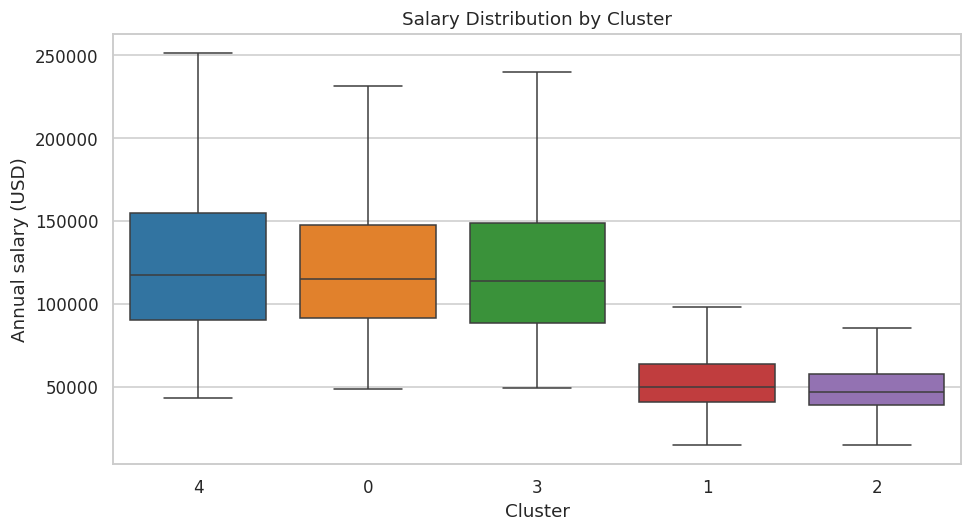

In [14]:
plt.figure(figsize=(9, 5))
order = profiles_df.sort_values("median_salary", ascending=False)["cluster"]
sns.boxplot(
    data=df_feat, x="cluster", y="normalized_salary", order=order,
    palette=palette, showfliers=False
)
plt.title("Salary Distribution by Cluster")
plt.ylabel("Annual salary (USD)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()


### 8.3 Remote-work share & average skill count per cluster

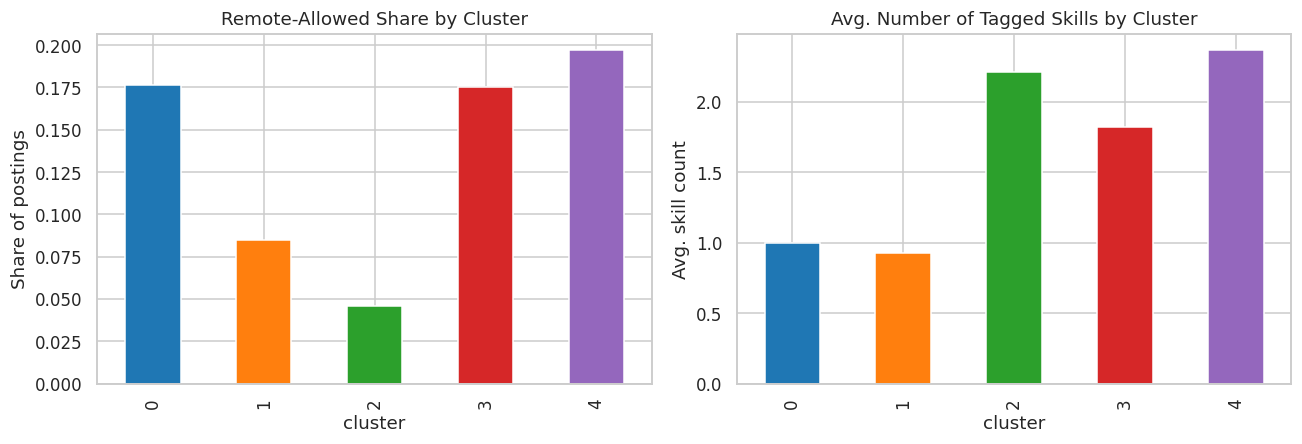

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

profiles_df.set_index("cluster")["remote_share"].sort_index().plot(
    kind="bar", ax=axes[0], color=[palette[c] for c in sorted(df_feat['cluster'].unique())]
)
axes[0].set_title("Remote-Allowed Share by Cluster")
axes[0].set_ylabel("Share of postings")

profiles_df.set_index("cluster")["avg_num_skills"].sort_index().plot(
    kind="bar", ax=axes[1], color=[palette[c] for c in sorted(df_feat['cluster'].unique())]
)
axes[1].set_title("Avg. Number of Tagged Skills by Cluster")
axes[1].set_ylabel("Avg. skill count")

plt.tight_layout()
plt.show()


### 8.4 Top skill categories per cluster (heatmap)

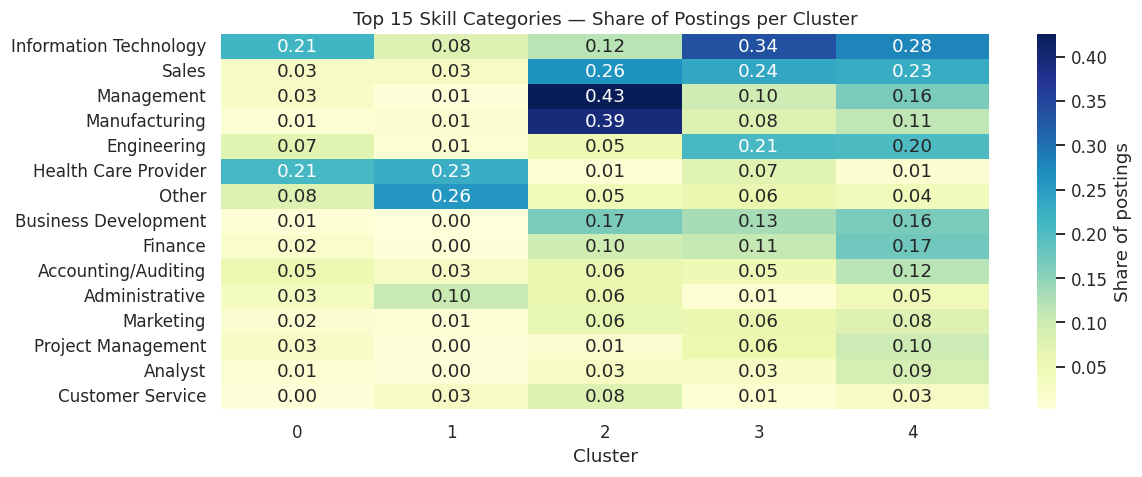

In [16]:
skill_means = df_feat.groupby("cluster")[prep.SKILL_COLUMNS].mean()
skill_means.columns = [prep.SKILL_MAP[a] for a in skill_means.columns]
top_skills_overall = skill_means.mean().sort_values(ascending=False).head(15).index

plt.figure(figsize=(11, 4.5))
sns.heatmap(skill_means[top_skills_overall].T, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={"label": "Share of postings"})
plt.title("Top 15 Skill Categories — Share of Postings per Cluster")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()


## 9. Persist Artifacts for the Streamlit App

We save:
- `models/preprocessor.pkl` — the **fitted** `ColumnTransformer`
- `models/kmeans_model.pkl` — the **fitted** `KMeans` model
- `models/pca.pkl` — the **fitted** `PCA` (for plotting new points in the
  app on the same 2D map)
- `models/cluster_profiles.json` — human-readable cluster summaries/labels
- `data/processed/clustered_jobs.csv` — the clustered dataset the app's
  "Explore" tab loads directly (no need to reprocess 500MB of raw data on
  every app launch)


In [17]:
joblib.dump(preprocessor, f"{MODELS_DIR}/preprocessor.pkl")
joblib.dump(kmeans, f"{MODELS_DIR}/kmeans_model.pkl")
joblib.dump(pca, f"{MODELS_DIR}/pca.pkl")

with open(f"{MODELS_DIR}/cluster_profiles.json", "w") as f:
    json.dump(profiles_df.to_dict(orient="records"), f, indent=2)

export_cols = [
    "job_id", "title", "company_name", "location",
    "normalized_salary", "formatted_experience_level", "work_type",
    "remote_allowed", "num_skills", "pca_1", "pca_2", "cluster",
]
df_feat[export_cols].to_csv(f"{DATA_PROCESSED}/clustered_jobs.csv", index=False)

print("Saved:")
print(f" - {MODELS_DIR}/preprocessor.pkl")
print(f" - {MODELS_DIR}/kmeans_model.pkl")
print(f" - {MODELS_DIR}/pca.pkl")
print(f" - {MODELS_DIR}/cluster_profiles.json")
print(f" - {DATA_PROCESSED}/clustered_jobs.csv  ({len(df_feat):,} rows)")


Saved:
 - ../models/preprocessor.pkl
 - ../models/kmeans_model.pkl
 - ../models/pca.pkl
 - ../models/cluster_profiles.json
 - ../data/processed/clustered_jobs.csv  (35,509 rows)


## 10. Summary

We segmented LinkedIn job postings into **5 data-driven market clusters**
using salary, skills, experience level, and remote-work availability,
selected via elbow + silhouette analysis. Each cluster has a distinct
profile (pay tier, seniority mix, dominant skill categories, remote
share) suitable for use by recruiters, analysts, or job-seekers.

**Next step:** run the companion **Streamlit app** (`app.py`) to explore
the clusters interactively and classify new job postings in real time —
see `README.md` for instructions.
